py_params_xal:
OrderedDict([('t0', 50.0), ('u0', 0.5), ('tE', 150.0), ('xi_para', 0.1), ('xi_perp', 0.0), ('xi_angular_velocity', 0.1815949510745545), ('xi_phase', 0.0), ('xi_inclination', 1.5707963267948966), ('xi_mass_ratio', 1.0), ('q_flux_G', 0.7), ('fsource_Simulation', 27.92543841237335), ('ftotal_Simulation', 27.92543841237335)])
Initial guess:
[ 50.    0.5 150. ]
Fit success = True
Fit message = Optimization terminated successfully.


/tmp/ipykernel_21809/2439217974.py:403: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


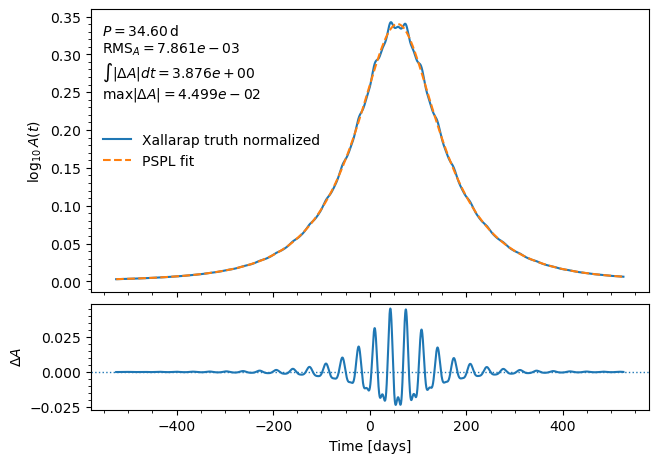


Best-fit (t0, u0, tE) = [ 57.49999545   0.49852013 150.05077992]
Truth    (t0, u0, tE) = [50.0, 0.5, 150.0]
RMS_A = 0.00786139174990814
RMS_F = 25.301303261948508
Int L1 = 3.875917803530817
Max |Delta A| = 0.044993213500736484


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import scipy.optimize as so
from scipy.interpolate import interp1d

from pyLIMA import event, telescopes
from pyLIMA.models import PSPL_model
from pyLIMA.simulations import simulator


# ============================================================
# Fotometría auxiliar
# ============================================================
ZP = 27.615

mag_grid = np.array([
    12.0, 12.5, 13.0, 13.5, 14.0, 14.5,
    15.0, 15.5, 16.0, 16.5, 17.0, 17.5,
    18.0, 18.5, 19.0, 19.5, 20.0, 20.5,
    21.0, 21.5, 22.0, 22.5, 23.0, 23.5,
    24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0
])

sigma_W149_grid = np.array([
    0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
    0.0010475, 0.0011229, 0.0012038, 0.0013207,
    0.0015178, 0.0017852, 0.002139, 0.0025867,
    0.0032066, 0.0039261, 0.0050352, 0.0063881,
    0.0082817, 0.01087, 0.014603, 0.019616,
    0.027602, 0.039749, 0.058585, 0.088371,
    0.13351, 0.20964, 0.32165, 0.51373, 1.0
])

sigma_interp_log = interp1d(
    mag_grid,
    np.log10(sigma_W149_grid),
    kind="linear",
    bounds_error=True
)


def sigma_W149_func(W149):
    W149 = np.asarray(W149)
    return 10**sigma_interp_log(W149)


def mag_to_flux(mag, zp=ZP):
    return 10**(-0.4 * (mag - zp))


def flux_to_mag(flux, zp=ZP):
    flux = np.asarray(flux)
    return zp - 2.5 * np.log10(flux)


def mag_from_flux(flux, zp=ZP):
    return zp - 2.5 * np.log10(np.abs(flux))


def sigma_flux_from_flux(flux, zp=ZP):
    flux = np.asarray(flux)
    mag = flux_to_mag(flux, zp=zp)
    sigma_mag = sigma_W149_func(mag)
    return (np.log(10) / 2.5) * flux * sigma_mag


# ============================================================
# Chi2 / SSE en magnificación
# ============================================================
def chi2_theoretical_magnification(
    fit_params,
    your_model,
    fs_fixed=1.0,
    fsecond_fixed=1.0,
):
    """
    Ajusta SOLO (t0, u0, tE) comparando:

        data = A_truth_eff

    contra:

        model = A_PSPL

    Ambos tienen baseline 1.
    """

    fit_params = np.asarray(fit_params, dtype=float)

    full_params = np.concatenate([
        fit_params,
        [fs_fixed, fsecond_fixed]
    ])

    py_params = your_model.compute_pyLIMA_parameters(full_params)

    sse = 0.0

    for tel in your_model.event.telescopes:

        if tel.lightcurve is None:
            continue

        data = tel.lightcurve["flux"].value

        model_pred = your_model.model_magnification(
            tel,
            py_params
        )

        resid = data - model_pred

        sse += np.sum(resid**2)

    return float(sse)


# ============================================================
# Evento simulado
# ============================================================
def build_sim_event(t, mag0=19.0, emag=1e-9, filt="G"):

    ev = event.Event()
    ev.name = "Simulated"
    ev.ra = 170
    ev.dec = -70

    lc = np.c_[
        t,
        np.full_like(t, mag0),
        np.full_like(t, emag)
    ]

    tel = telescopes.Telescope(
        name="Simulation",
        camera_filter=filt,
        lightcurve=lc.astype(float),
        lightcurve_names=["time", "mag", "err_mag"],
        lightcurve_units=["JD", "mag", "mag"],
        location="Earth",
    )

    ev.telescopes.append(tel)

    return ev


# ============================================================
# Main
# ============================================================
def single_period_fit_and_plot(
    P_days: float,
    t0_true: float = 50.0,
    u0_true: float = 0.1,
    tE_true: float = 173.0,
    xiE: float = 0.1,
    theta: float = 0.0,
    phi0: float = 0.0,
    lambda_xi: float = 0.5*np.pi,
    q_mass: float = 1.0,
    qflux: float = 0.0,
    ms: float = 24.0,
    mtotal: float = 24.0,
    override_xiE: float | None = None,
    window_k: float | None = None,
    out_prefix: str = "singleP",
):

    # ========================================================
    # Tiempo
    # ========================================================
    t = np.linspace(
        -3.5*tE_true,
        3.5*tE_true,
        10000
    )

    omega = 2.0*np.pi / float(P_days)

    if override_xiE is not None:
        xiE_use = float(override_xiE)
    else:
        xiE_use = float(xiE)

    xi_para = xiE_use * np.cos(theta)
    xi_perp = xiE_use * np.sin(theta)

    # ========================================================
    # Evento
    # ========================================================
    ev = build_sim_event(
        t,
        mag0=19.0,
        emag=1e-9,
        filt="G"
    )

    # ========================================================
    # Modelo verdadero: xallarap / fuente binaria
    # ========================================================
    model_xal = PSPL_model.PSPLmodel(
        ev,
        parallax=["None", 0.0],
        double_source=["Circular", t0_true]
    )

    model_xal.define_model_parameters()

    fs = mag_to_flux(ms, zp=ZP)
    ftotal = mag_to_flux(mtotal, zp=ZP)

    params_xal = [
        t0_true,
        u0_true,
        tE_true,
        xi_para,
        xi_perp,
        omega,
        phi0,
        lambda_xi,
        q_mass,
        qflux,
        fs,
        ftotal,
    ]

    py_params_xal = model_xal.compute_pyLIMA_parameters(params_xal)

    print("py_params_xal:")
    print(py_params_xal)

    simulator.simulate_lightcurve(model_xal, py_params_xal)

    F_truth = model_xal.compute_the_microlensing_model(
        ev.telescopes[0],
        py_params_xal
    )["photometry"]

    A_truth = model_xal.model_magnification(
        ev.telescopes[0],
        py_params_xal
    )

    # ========================================================
    # Magnificación efectiva normalizada
    # ========================================================
    A_truth_eff = A_truth / (1.0 + qflux)

    # IMPORTANTE:
    # Para ajustar magnificación, guardamos A_truth_eff como "data".
    ev.telescopes[0].lightcurve["flux"] = A_truth_eff

    # La magnitud se guarda solo como auxiliar visual, no para el fit.
    ev.telescopes[0].lightcurve["mag"] = mag_from_flux(F_truth, zp=ZP)

    # ========================================================
    # Modelo de ajuste: PSPL
    # ========================================================
    model_pspl = PSPL_model.PSPLmodel(
        ev,
        parallax=["None", 0.0],
        double_source=["None", 0.0]
    )

    model_pspl.define_model_parameters()

    x0 = np.array(
        [t0_true, u0_true, tE_true],
        dtype=float
    )

    print("Initial guess:")
    print(x0)

    res = so.minimize(
        chi2_theoretical_magnification,
        x0=x0,
        args=(model_pspl, fs, ftotal),
        method="Nelder-Mead",
        options=dict(
            maxiter=200000,
            xatol=1e-10,
            fatol=1e-6
        ),
    )

    print("Fit success =", res.success)
    print("Fit message =", res.message)

    if not res.success:
        raise RuntimeError(f"Fit failed: {res.message}")

    best = np.asarray(res.x, dtype=float)

    best_full = np.concatenate([
        best,
        [fs, ftotal]
    ])

    py_best = model_pspl.compute_pyLIMA_parameters(best_full)

    F_fit = model_pspl.compute_the_microlensing_model(
        ev.telescopes[0],
        py_best
    )["photometry"]

    A_fit = model_pspl.model_magnification(
        ev.telescopes[0],
        py_best
    )

    # ========================================================
    # Residuos consistentes
    # ========================================================
    resid_A = A_truth_eff - A_fit

    # El residuo en flujo es solo diagnóstico, no el ajuste.
    resid_F = F_truth - F_fit

    if window_k is not None:
        mask = np.abs(t - t0_true) <= float(window_k)*tE_true
    else:
        mask = np.ones_like(t, dtype=bool)

    rms_A = float(np.sqrt(np.mean(resid_A[mask]**2)))
    rms_F = float(np.sqrt(np.mean(resid_F[mask]**2)))
    int_L1 = float(np.trapz(np.abs(resid_A[mask]), t[mask]))
    max_abs_A = float(np.max(np.abs(resid_A[mask])))

    # ========================================================
    # Plot magnificación
    # ========================================================
    fig = plt.figure(figsize=(7.2, 5.2))

    gs = fig.add_gridspec(
        2,
        1,
        height_ratios=[3.2, 1.2],
        hspace=0.06
    )

    ax = fig.add_subplot(gs[0, 0])
    axr = fig.add_subplot(gs[1, 0], sharex=ax)

    ax.plot(
        t[mask],
        np.log10(A_truth_eff[mask]),
        label="Xallarap truth normalized"
    )

    ax.plot(
        t[mask],
        np.log10(A_fit[mask]),
        "--",
        label="PSPL fit"
    )

    ax.set_ylabel(r"$\log_{10} A(t)$")
    ax.legend(frameon=False, loc="best")

    ax.text(
        0.02,
        0.95,
        rf"$P={P_days:.2f}\,\mathrm{{d}}$"
        + "\n"
        + rf"$\mathrm{{RMS}}_A={rms_A:.3e}$"
        + "\n"
        + rf"$\int |\Delta A| dt={int_L1:.3e}$"
        + "\n"
        + rf"$\max |\Delta A|={max_abs_A:.3e}$",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        ),
    )

    axr.plot(
        t[mask],
        resid_A[mask]
    )

    axr.axhline(
        0.0,
        linestyle=":",
        linewidth=1.0
    )

    axr.set_xlabel("Time [days]")
    axr.set_ylabel(r"$\Delta A$")

    ax.yaxis.set_minor_locator(AutoMinorLocator())
    axr.yaxis.set_minor_locator(AutoMinorLocator())
    axr.xaxis.set_minor_locator(AutoMinorLocator())

    plt.setp(ax.get_xticklabels(), visible=False)

    fig.tight_layout()

    fig.savefig(
        f"{out_prefix}_mag.pdf",
        bbox_inches="tight"
    )

    fig.savefig(
        f"{out_prefix}_mag.png",
        bbox_inches="tight"
    )

    plt.show()

    # ========================================================
    # Prints
    # ========================================================
    print()
    print("Best-fit (t0, u0, tE) =", best)
    print("Truth    (t0, u0, tE) =", [t0_true, u0_true, tE_true])
    print("RMS_A =", rms_A)
    print("RMS_F =", rms_F)
    print("Int L1 =", int_L1)
    print("Max |Delta A| =", max_abs_A)

    return dict(
        t=t,
        mask=mask,
        best=best,
        F_truth=F_truth,
        F_fit=F_fit,
        A_truth=A_truth,
        A_truth_eff=A_truth_eff,
        A_fit=A_fit,
        resid_A=resid_A,
        RMS_A=rms_A,
        RMS_F=rms_F,
    )


# ============================================================
# Ejecución
# ============================================================
plt.close("all")

out = single_period_fit_and_plot(
    P_days=173/5,
    t0_true=50.0,
    u0_true=0.5,
    tE_true=150.0,
    xiE=0.1,
    theta=0.0,
    phi0=0.0,
    lambda_xi=0.5*np.pi,
    q_mass=1.0,
    qflux=0.70,
    ms=24.0,
    mtotal=24.0,
    override_xiE=None,
    window_k=5.0,
    out_prefix="singleP_210d",
)

In [13]:
from astropy import units as u
tE1 = 124*u.day
omega1 = -1.401e-3*(1/u.day)
P1 = 2*np.pi/abs(omega1)
print((P1/tE1).decompose())

36.16762972979891
